# Abbiategrasso: confronto IRPEF nel Sud Ovest milanese

Approfondimento leggero del filone IRPEF locale.

Obiettivo:
- verificare se Abbiategrasso cambia posizione dentro un perimetro piu' stretto del Sud Ovest milanese
- capire se il benchmark IRPEF gia' usato basta o se conviene distinguere tra confronto allargato e confronto territoriale stretto


## Export figure

Le figure di questa repo nascono nei notebook e vengono esportate in `figures/`.
Il notebook resta eseguito e leggibile su GitHub, ma il PNG esportato e' il riferimento stabile per README e note.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path.cwd().resolve().parent
wide_csv_path = repo_root / 'data' / 'abbiategrasso_irpef_benchmark_2019_2023.csv'
sw_csv_path = repo_root / 'data' / 'abbiategrasso_irpef_sud_ovest_2019_2023.csv'
figures_dir = repo_root / 'figures'
figures_dir.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')


def save_figure(fig, name: str):
    path = figures_dir / name
    fig.savefig(path, dpi=160, bbox_inches='tight')
    return path

wide_df = pd.read_csv(wide_csv_path, dtype={'codice_comune': str})
sw_df = pd.read_csv(sw_csv_path, dtype={'codice_comune': str})
wide_df['comune_label'] = wide_df['comune'].str.title()
sw_df['comune_label'] = sw_df['comune'].str.title()

## 1. Posizione di Abbiategrasso nei due benchmark

Confrontiamo il ranking `2023` nel benchmark gia' usato e nel set piu' stretto del Sud Ovest milanese.


In [2]:
wide_2023 = wide_df[wide_df['anno_imposta'] == 2023].sort_values('reddito_imponibile_medio_per_contribuente_eur', ascending=False).reset_index(drop=True)
sw_2023 = sw_df[sw_df['anno_imposta'] == 2023].sort_values('reddito_imponibile_medio_per_contribuente_eur', ascending=False).reset_index(drop=True)

wide_rank = int(wide_2023.index[wide_2023['comune'] == 'ABBIATEGRASSO'][0]) + 1
sw_rank = int(sw_2023.index[sw_2023['comune'] == 'ABBIATEGRASSO'][0]) + 1

comparison = pd.DataFrame([
    {
        'benchmark': 'allargato',
        'comuni': len(wide_2023),
        'rank_abbiategrasso': wide_rank,
        'reddito_medio_abbiategrasso_eur': round(wide_2023[wide_2023['comune'] == 'ABBIATEGRASSO']['reddito_imponibile_medio_per_contribuente_eur'].iloc[0], 2),
    },
    {
        'benchmark': 'sud_ovest_milanese',
        'comuni': len(sw_2023),
        'rank_abbiategrasso': sw_rank,
        'reddito_medio_abbiategrasso_eur': round(sw_2023[sw_2023['comune'] == 'ABBIATEGRASSO']['reddito_imponibile_medio_per_contribuente_eur'].iloc[0], 2),
    },
])
comparison

,benchmark,comuni,rank_abbiategrasso,reddito_medio_abbiategrasso_eur
0,allargato,6,3,25401.99
1,sud_ovest_milanese,9,6,25401.99


Lettura minima:

- nel benchmark IRPEF gia' usato Abbiategrasso e' `3 su 6`
- nel perimetro piu' stretto del Sud Ovest milanese scende a `6 su 9`
- la differenza non viene da un peggioramento di Abbiategrasso, ma dal fatto che entrano comuni piu' vicini con redditi medi piu' alti come Corbetta, Gaggiano e Trezzano sul Naviglio


## 2. Sud Ovest milanese: ranking 2023

Guardiamo solo il set piu' stretto del Sud Ovest milanese.


WindowsPath('C:/Users/gabry/OneDrive/Desktop/dataciviclab-workspace/abbiategrasso-data-notes/figures/abbiategrasso_irpef_sud_ovest_2023.png')

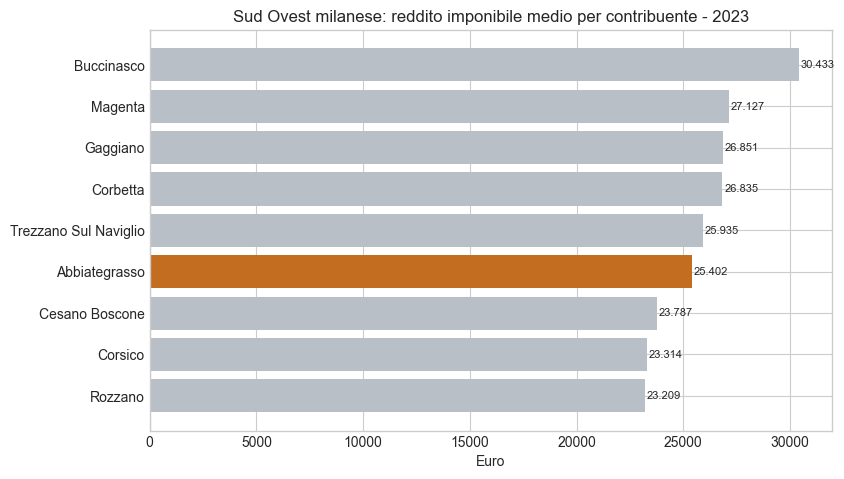

In [3]:
sw_plot = sw_2023.sort_values('reddito_imponibile_medio_per_contribuente_eur', ascending=True)
colors = ['#c26d1f' if comune == 'Abbiategrasso' else '#b8bfc6' for comune in sw_plot['comune_label']]

fig, ax = plt.subplots(figsize=(8.8, 5.2))
bars = ax.barh(sw_plot['comune_label'], sw_plot['reddito_imponibile_medio_per_contribuente_eur'], color=colors)
ax.set_title('Sud Ovest milanese: reddito imponibile medio per contribuente - 2023')
ax.set_xlabel('Euro')
ax.set_ylabel('')

for bar, value in zip(bars, sw_plot['reddito_imponibile_medio_per_contribuente_eur']):
    label = f"{value:,.0f}".replace(',', '.')
    ax.text(value + 80, bar.get_y() + bar.get_height() / 2, label, va='center', fontsize=8)

sw_fig_path = save_figure(fig, 'abbiategrasso_irpef_sud_ovest_2023.png')
sw_fig_path

Lettura minima del set territoriale stretto:

- Buccinasco resta nettamente fuori scala rispetto al resto del gruppo
- Magenta, Corbetta, Gaggiano e Trezzano sul Naviglio stanno tutte sopra Abbiategrasso
- Abbiategrasso resta comunque sopra Cesano Boscone, Corsico e Rozzano


## 3. Uso pratico dei due benchmark

La lettura piu' utile, per ora, e' questa:

- benchmark allargato: buono per una prima fotografia locale leggibile e non troppo affollata
- benchmark Sud Ovest milanese: piu' utile quando la domanda e' davvero territoriale e voglio capire dove si colloca Abbiategrasso tra comuni piu' vicini

Non serve ancora scegliere un benchmark unico per sempre.
